In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data Generation for the Curve Fitting Chapter

## TODO

- Rename data files to make exercises more modular

## Exercise: Least Squares

In [2]:
def least_squares(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    #Note that the expectation values can be calculated using the mean function
    expect_xy = np.mean(x*y)
    expect_xx = np.mean(x*x)
    
    a1 = (expect_xy - mean_x*mean_y)/(expect_xx - mean_x*mean_x)

    return mean_y - a1*mean_x, a1

def u_lsq(x, y, a0, a1):
    uy = np.sqrt(np.sum((a0 + a1*x - y)**2) / (x.size - 2))

    e_x = np.mean(x)
    e_xx = np.mean(x * x)
    D = (e_xx - e_x * e_x)
    
    ua0 = np.sqrt(uy * uy * e_xx / D / x.size)
    
    ua1 = np.sqrt(uy * uy / D / x.size)

    return uy, ua0, ua1


### Question 2

Determining constants from Cepheid Variables

In [3]:
logP, M, color = np.loadtxt('../data/cepheid_data.csv', delimiter = ',', skiprows = 1, unpack = True)

a0, a1 = least_squares(logP, M)
uy, ua0, ua1 = u_lsq(logP, M, a0, a1)

print('a0', a0)
print('a1', a1)
print('uy', uy)
print('ua0', ua0)
print('ua1', ua1)

a0 -1.619033264793699
a1 -2.54732312970848
uy 0.2836785277443489
ua0 0.15139784299976927
ua1 0.12757667951220314


In [20]:
logP.size

33

### Question 3

Determine the constants of a seemingly non-linear soluion:

$$
y = a_0 + a_1 \tanh(x)
$$


a0 5.381067927944397
a1 3.3053825762289466
uy 3.35375495366633
ua0 0.9345312578349172
ua1 0.5368199475038923


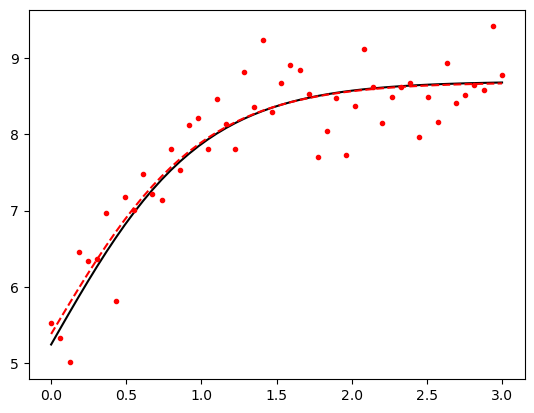

In [5]:
gen_data = False
fname = 'data_lsqr_01.csv'

count = 50
x_lims = (0, 3)
sigma = 0.4

a0 = 5.243
a1 = 3.45646

def f(x, a0, a1):
    return a0 + a1 * np.tanh(x) # np.exp(x)

if gen_data:
    x_data = np.linspace(*x_lims, count)
    y_data = np.random.normal(f(x_data, a0, a1), sigma)
    np.savetxt(fname, np.array((x_data, y_data)).T, delimiter=',', header='x,y')
else:
    x_data, y_data = np.loadtxt(fname, delimiter=',', unpack=True)

plt.plot(x_data, f(x_data, a0, a1), 'k-')

plt.plot(x_data, y_data, 'r.')

a_fit = least_squares(np.tanh(x_data), y_data)
u_fit = u_lsq(x_data, y_data, *a_fit)

for lbl, val in zip(
    ('a0', 'a1', 'uy', 'ua0', 'ua1'),
    a_fit + u_fit
):
    print(lbl, val)

plt.plot(x_data, f(x_data, *a_fit), '--r')

plt.show()

## Exercise: $\chi^2$ min

In [25]:
def chi_squares(x, y, sigma):
    ss_inv = 1/ sigma / sigma
    
    e_1_ss = np.mean(ss_inv)
    e_y_ss = np.mean(y * ss_inv)
    e_xy_ss = np.mean(x * y * ss_inv)
    e_xx_ss = np.mean(x * x * ss_inv)
    e_x_ss = np.mean(x * ss_inv)
    

    D = e_1_ss * e_xx_ss - e_x_ss * e_x_ss

    a0 = (e_y_ss * e_xx_ss - e_x_ss * e_xy_ss) / D
    a1 = (e_1_ss * e_xy_ss - e_x_ss * e_y_ss) / D

    u_a0 = np.sqrt(e_xx_ss / x.size / D)
    u_a1 = np.sqrt(e_1_ss / x.size / D)
    
    return a0, a1, u_a0, u_a1

In [27]:
fname = 'data_chisqr_01.txt'

y, s, x = np.loadtxt(fname, unpack=True)

a_fit = chi_squares(x, y, s)

for lbl, val in zip(
    ('a0', 'a1', 'u(a0)', 'u(a1)'),
    a_fit
):
    print(lbl, val)

a0 2.8110257565325547
a1 17.13476436993958
u(a0) 4.633653306181554
u(a1) 0.5696948642415929
